In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 19: Geração de novas imagens com GANs

## Etapa 1: Importação das bibliotecas

## Redes Adversariais Generativas (GAN - Generative Adversarial Networks)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
torch.__version__

'2.9.1+cpu'

In [3]:
# para termos a mesma reprodutibilidade dos experimentos, em todas as etapas. Isso a qualquer hora.
torch.manual_seed(123)

## Etapa 2: Base de dados

In [4]:
# para colocarmos já no formato do to tensor
transform = transforms.ToTensor()
train = datasets.MNIST(root = '.', train = True, download = True,
                       transform = transform)
train_loader = torch.utils.data.DataLoader(train, batch_size = 256) # otreinamento será feito de 256 a 256 imagens


Carregar somenta essa base de dados de treinamento, pois o objetivo é treinar com uma base de dados. Treinar com uma base de dados só. Não vamos verificar a precisão do algoritmo, não é nosso ojetivo principal. 

### Nosso objetivo é verificar como ele vai gera as novas imagens. 

    

Avaliação abstrata e manualmente, verificando as imagens e verificar se ela está conseguindo gerar os digitos manuscritos.  

## Construir a rede neural do gerador, a primeira rede 

Duas redes neurais, gerador e discriminador, a primeira geradora recebe valores aleatórios. Sendo que ela vai gerar imagens. Passa pelas camadas das redes neurais, gerando imagens, a medida que o modelo vai aprimorando, vai criando imagens mais reais. 

Trabalhando com a geração de novos dígitos na mão. A saída da rede neural, terá novos dígitos gerados na mão. A camada de saída do gerador não será somente 2 neurônio, mas será de acordo com a quantidade ou a dimensionalidade das imagens. No caso do MNIST nós temos imagens 28 por 28 pixels, Multiplicar os valores altura por lagura teremos 784 pixels. 

In [5]:
28*28

784

Teremos então 784 saídas que vão representar uma imagem. 

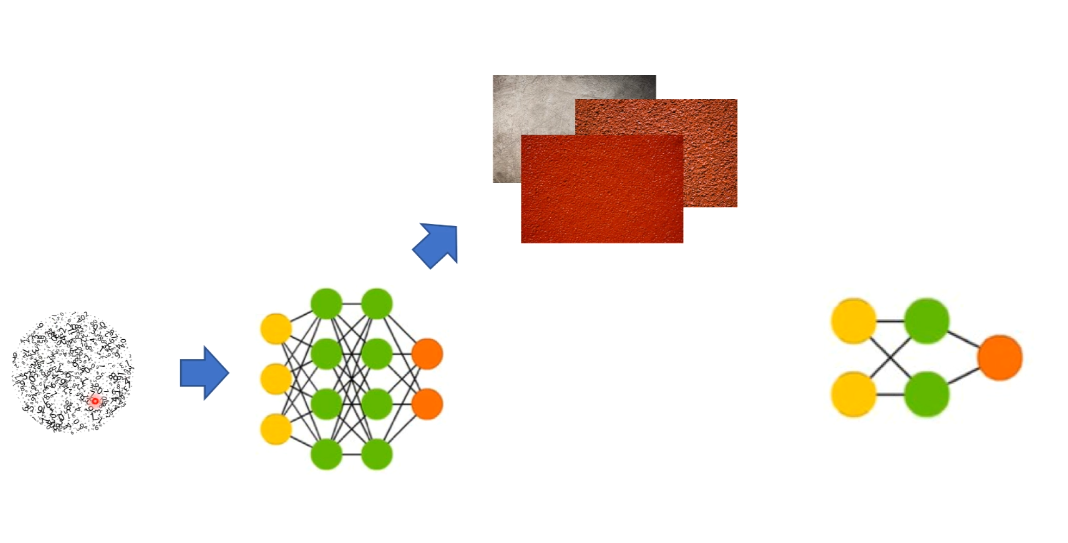

## Etapa 3: Construção do gerador

Zerar 30% dos neurônios (o Dropout) é uma técnica de "treinamento de elite". Imagine que você está treinando um time: se você sempre depender dos mesmos 2 ou 3 jogadores craques, o resto do time fica preguiçoso. O Dropout "tira" esses craques de campo aleatoriamente para forçar todos os outros neurônios a aprenderem a resolver o problema sozinhos.

In [6]:
# criar a classe geradora. 
class gerador(nn.Module):
  def __init__(self):
    # chamando o construtor da super classe   
    super().__init__()      
    # definir as camadas, que será densa e linear.
    # 100 neurônios na camada da rede neura,
    # que recebe vetor de ruído de números aleatórios, contendo esses 100 elementos.     
    # essa entrada a 100, equivale aos números aleatórios no exemplo acima.
    # 100 na camada de entrada usado muito na literatura de GANs  
    # 100 na camada de entrada -> 32 neurônios na camada escondida
    #  -> (32 ligados ao neurônio de 64) 64 -> camada anterior para a próxima camada 128 neurônios-> 784 neurônios (28x28 pixels)
    # Camadas Densas (Lineares): O caminho do ruído até a imagem final
    # 100 (Ruído Inicial) -> 32 -> 64 -> 128 -> 784 (Imagem 28x28)
      
    # final exemplo do passo a passo  
    # 100 -> 32 -> 64 -> 128 -> 784
    self.dense0 = nn.Linear(100, 32)
    self.dense1 = nn.Linear(32, 64)
    self.dense2 = nn.Linear(64, 128)
    self.dense3 = nn.Linear(128, 784)
    self.dropout = nn.Dropout(0.3) # zerar 30% dos neurônios
    # O DROPOUT (0.3 = 30%): Para evitar o "Overfitting" (decorar os dados).
    # Isso força a rede a não confiar em apenas um caminho de neurônios,
    # tornando o gerador mais robusto e criativo, gerando imagens mais variadas.
  def forward(self, X): # para fazer as ligações das camadas
    # Relu, valores negativos é zerado 
    # já no o leaky_relu multiplica-se os valores negativos por um fator que nós vamos definir.
    # Colocando esse valor como 0.2, para o gradiente chegar as camadas mais profundos (isso no leaky_relu). 
    # Leaky ReLU (0.2): É uma versão da ReLU que deixa passar um pouquinho 
    # de sinal negativo. Nas GANs, isso ajuda a evitar que os neurônios "morram"
    # (fenômeno chamado de Dying ReLU), mantendo o gradiente fluindo.
    X = self.dropout(F.leaky_relu(self.dense0(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense1(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense2(X), 0.2))
    ## tangente hierbólica, que se passa na camada 3. Teremos a reposta real, com 784 valores. Com valores -1 e 1.
    # Tanh (Tangente Hiperbólica): Na última camada, usamos Tanh para que os 
    # valores dos pixels fiquem entre -1 e 1 (comum em GANs).
    X = torch.tanh(self.dense3(X))
    # converte a imagem     
    # 784 pixels, convertendo para altura e largura, 28
    # formato de matriz, raiz quadrada.  
    # .view: Transforma o vetor chato de 784 pixels de volta no formato 
    # de uma imagem quadrada de 28x28 para podermos visualizar.      
    X = X.view(X.shape[0], 28, 28)
    return X

In [7]:
import math
math.sqrt(784)

28.0

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} & 
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} & 
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} & 
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} & 
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} & 
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

## Etapa 4: Construção do discriminador

segunda rede neural, discriminador, que receberá as imagens fakes ou geradores, e também receberá as imagens armazenadas reais dos animais, e agora fará a classificação binária simples, um valor só, se é ou não é 0 ou 1.

Classe das imagens falsas, e outra classe das imagens verdadeiras. 

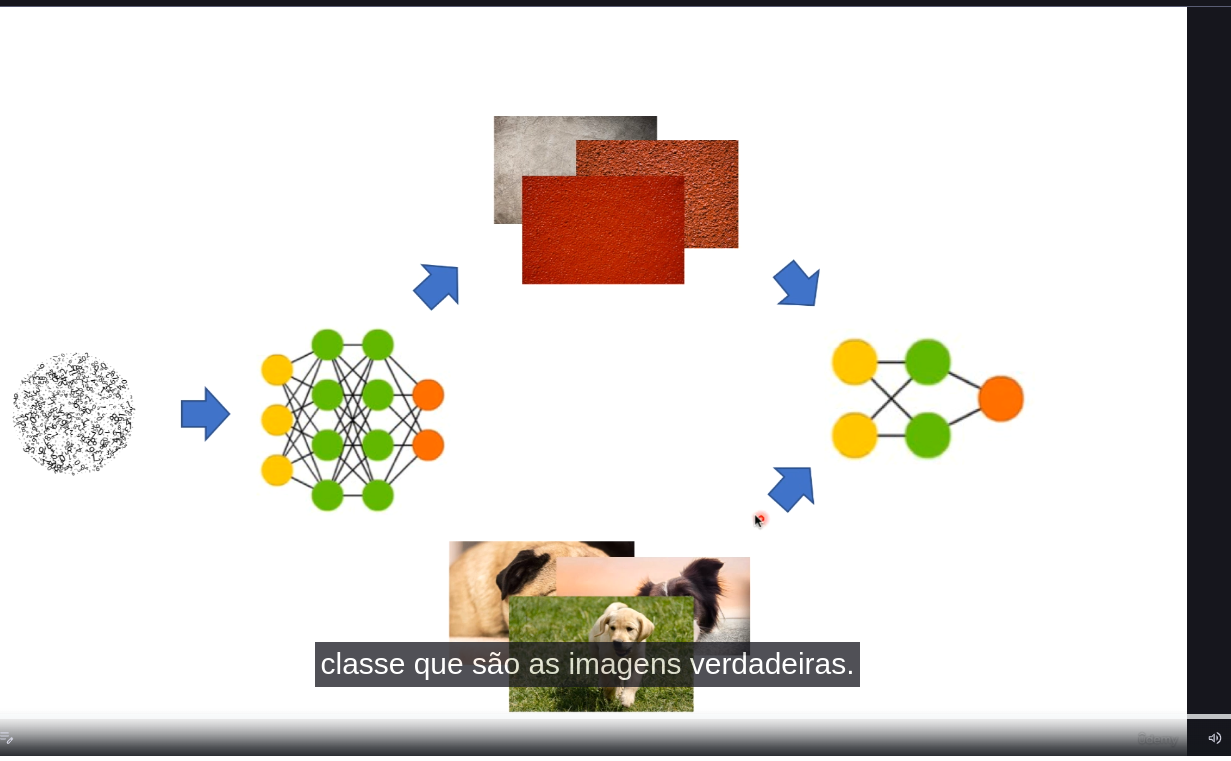

In [8]:
# CRIANDO A CLASSE DISCRIMINADORA (O "Juiz" que detecta falsificações)
class discriminador(nn.Module):
  def __init__(self): # contrutor da classe
    # super().__init__(): Inicializa os componentes base do PyTorch.  
    super().__init__() # construção da classe módulo
    # O fluxo de dados aqui é de FUNIL (redução de dimensionalidade):
    # 784 (Pixels) -> 128 -> 64 -> 32 -> 1 (Veredito final)
    
    # 784 -> 128 -> 64 -> 32 -> 1
    # receber as imagwens, com a rede neural simples linear.  
    # self.dense0: Recebe a imagem de 784 pixels e reduz para 128 neurônios.  
    self.dense0 = nn.Linear(784, 128)

    # self.dense1: Reduz a complexidade de 128 para 64 neurônios.      
    self.dense1 = nn.Linear(128, 64)
      
    # self.dense2: Refina as características de 64 para 32 neurônios.      
    self.dense2 = nn.Linear(64, 32)
      
    # self.dense3: Camada Crítica. Reduz os 32 neurônios para APENAS 1 neurònio na camada de saida.
    # Este único neurônio dirá se a imagem é Real (próximo de 1) ou Falsa (próximo de 0).      
    self.dense3 = nn.Linear(32, 1) # gera imagenm real ou falsa.
      
    # self.dropout (0.3): Importantíssimo aqui!  Zerar 30% dos neurônios. 
    # Impede que o Discriminador fique "inteligente demais" rápido demais.
    # Se o juiz for perfeito logo de cara, o Gerador nunca consegue aprender nada.      
    self.dropout = nn.Dropout(0.3)

  def forward(self, X):
    # X.view: Garante que a imagem (28x28) seja "achatada" em uma linha de 784 
    # elementos antes de entrar na primeira camada linear.   
    X = X.view(X.shape[0], 28 * 28) # converter o x para o 784 matriz para um vetor (parte de conversor de leitura).
    # F.leaky_relu(..., 0.2): Ativação que mantém o aprendizado vivo. E se tiver valores negativos, multiplica por 0,2
    # Usamos o Dropout após cada ativação para forçar o juiz a olhar para 
    # diferentes partes da imagem para tomar sua decisão.      
    X = self.dropout(F.leaky_relu(self.dense0(X), 0.2))
      
    # Repete o processo nas camadas intermediárias  
    X = self.dropout(F.leaky_relu(self.dense1(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense2(X), 0.2))

    # Camada final: Retorna o valor bruto (logit). 
    # Geralmente, usaremos uma função de perda (como BCEWithLogitsLoss) 
    # depois disso para treinar o modelo.      
    X = self.dense3(X) # resultado (não definimos uma função sigmoid
    return X

## Etapa 5: Criação dos objetos

In [9]:
# criado dois objetos das classes
G = gerador()
D = discriminador()

In [10]:
# precisamos de otimizadores para o gerador e para o discriminador
# 1. G_optimizer = optim.Adam(G.parameters(), lr = 0.002):
# Este é o otimizador exclusivo do GERADOR (G).
# - G.parameters(): Dá ao Adam o controle total sobre os pesos do Gerador.
# - lr = 0.002 (Learning Rate): Define a velocidade de aprendizado. 
#   0.002 é uma taxa comum em GANs para permitir que o Gerador mude 
#   seus "desenhos" rapidamente para tentar enganar o juiz.
# O objetivo aqui é AJUSTAR o Gerador para que o erro do Juiz aumente.
G_optimizer = optim.Adam(G.parameters(), lr = 0.002)

# 2. D_optimizer = optim.Adam(D.parameters(), lr = 0.002):
# Este é o otimizador exclusivo do DISCRIMINADOR (D).
# - D.parameters(): Dá ao Adam o controle sobre os pesos do Juiz/Policial.
# - Ele funciona de forma independente do Gerador. Enquanto o Gerador tenta 
#   enganar, este otimizador tenta tornar o Discriminador mais "esperto" 
#   para detectar imagens falsas.
# O objetivo aqui é AJUSTAR o Discriminador para que ele não seja enganado.
D_optimizer = optim.Adam(D.parameters(), lr = 0.002)

In [11]:
# combina a camada sigmoid e uma camada binari logits loss, combina os dois processos. 
# A união dos doos processos é mais estável. 
# criterion = nn.BCEWithLogitsLoss():
# 1. BCE (Binary Cross Entropy): É a medida de erro para decisões binárias.
#    Ela calcula a distância entre a previsão do juiz e a realidade:
#    - Se a imagem é REAL, o alvo é 1.
#    - Se a imagem é GERADA (Falsa), o alvo é 0.
#
# 2. WithLogits: Esta é a parte "mágica". 
#    Lembra que no Discriminador a última camada não tem Sigmoid? 
#    Esta função aplica o Sigmoid internamente de forma matematicamente estável.
#    Isso evita erros numéricos (como divisões por zero ou números infinitos) 
#    que costumam quebrar o treino de uma GAN.
#
# 3. O Objetivo: 
#    - Pro Discriminador: Ele quer que essa perda seja ZERO ao identificar 
#      reais como 1 e falsas como 0.
#    - Pro Gerador: Ele quer que o juiz erre, forçando essa perda a ser 
#      calculada como se a imagem falsa fosse "1".
criterion = nn.BCEWithLogitsLoss()

In [12]:
# recebe os dados brutos e fazer a transformação WithLogits

In [13]:
# buscando o dispositivo
# 1. torch.cuda.is_available():
# O PyTorch pergunta ao Windows/Linux: "Existe uma placa de vídeo NVIDIA 
# com drivers CUDA instalados e prontos para uso?"

# 2. torch.device('cuda'):
# Se a resposta for SIM, o objeto 'device' guardará o endereço da GPU.
# Treinar uma GAN na GPU é cerca de 10x a 50x mais rápido do que no processador.

# 3. torch.device('cpu'):
# Se a resposta for NÃO (ou se você estiver em um Mac/PC sem placa dedicada), 
# o 'device' guardará o endereço do seu processador central (CPU).

# 4. device:
# Ao digitar apenas 'device' no final, o Jupyter/Colab imprime o resultado:
# 'cuda' ou 'cpu', para você saber onde seu modelo vai morar.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [14]:
# resumo das redes neurais
G.to(device)

gerador(
  (dense0): Linear(in_features=100, out_features=32, bias=True)
  (dense1): Linear(in_features=32, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=128, bias=True)
  (dense3): Linear(in_features=128, out_features=784, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [15]:
D.to(device)

discriminador(
  (dense0): Linear(in_features=784, out_features=128, bias=True)
  (dense1): Linear(in_features=128, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=32, bias=True)
  (dense3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

# O treinamento dividido em 2. Temos que treinar o gerador e o discriminador

## Etapa 6: Treinamento do modelo

- Gerador precisa ser especialista em gerar imagens falsas que pareçam com as imagens originais;

- O discriminador precisa ser especialista para identificar se a imagem é falsa ou verdadeira; 

        # * O Gerador passa as imagens falsas para o Discriminador (D)
        # passando a imagem para o discriminador
        # * Lembrando que a função do discriminador indica o quão longe o gerador está de gerar imagens reais. 
        # passando para o discriminador, no final do neurônio da saída, é apenas , se é ou não de um aninal ou não. 
        # se 1 próximo de ser um cachorro, por exemplo

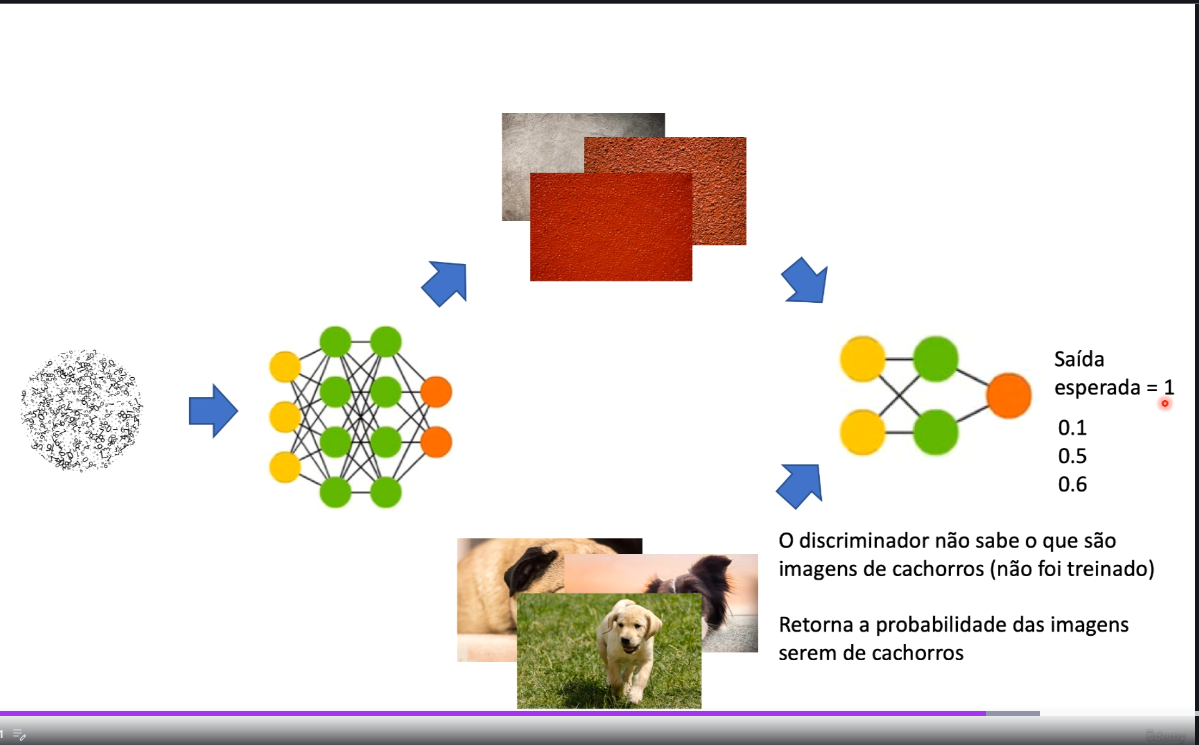

        # Calcula o erro baseado no quão longe o D está de ser enganado
        # criterion, função do erro. E o view é para deixar tudo na mesma dimensionalidade
        # previsão da rede neural com o labels falsas com o valor 1.

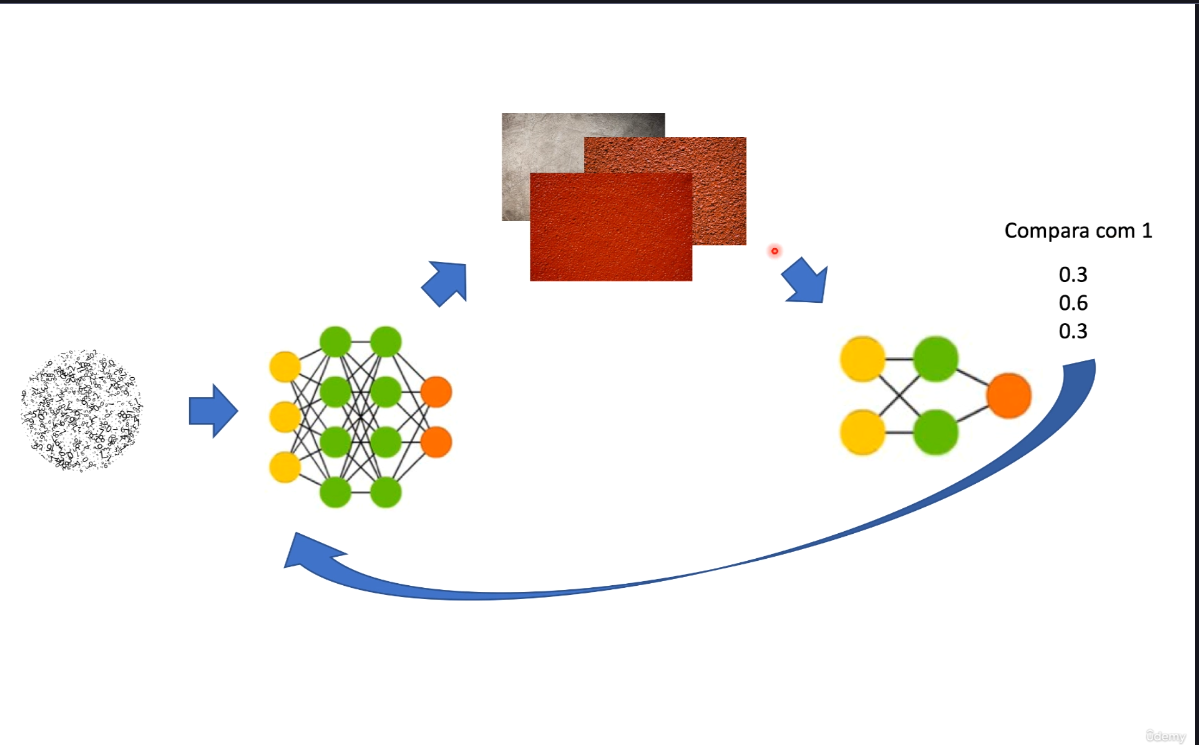

Discriminador agora

com problema de classificação binária

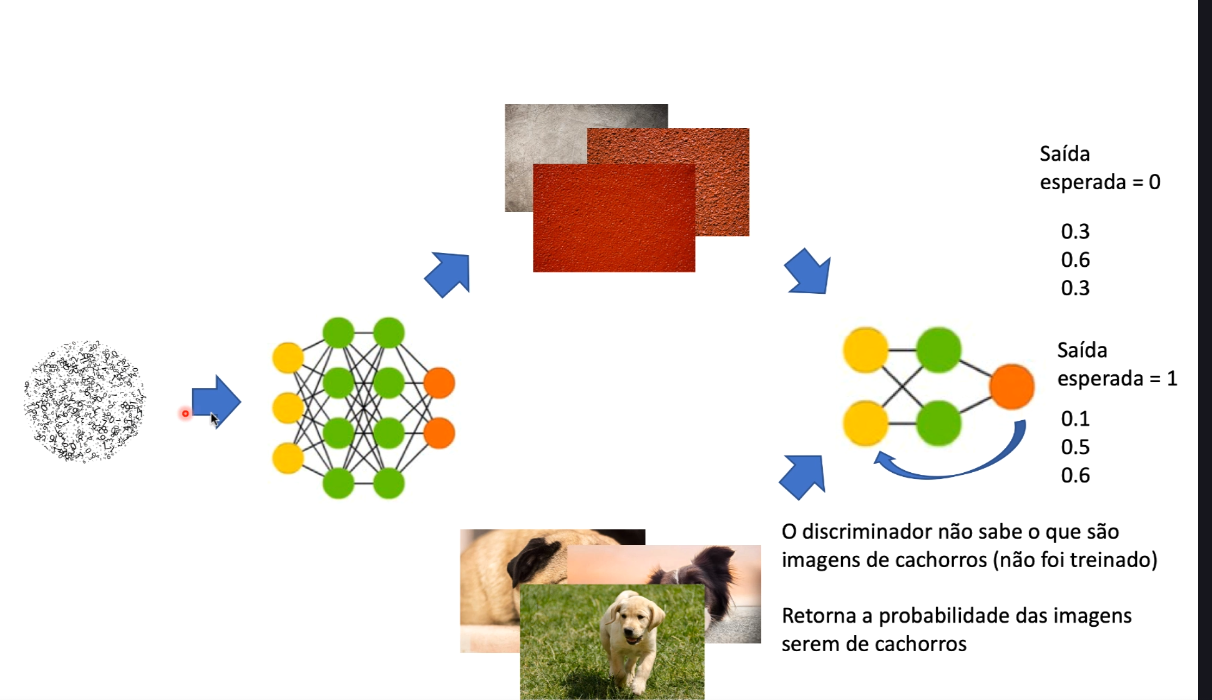

ÉPOCA 001 finalizada: custo discriminador 0.867883 - custo gerador 2.860527      


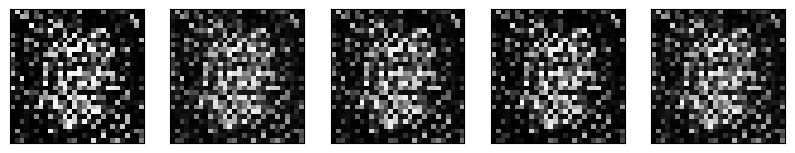

ÉPOCA 002 finalizada: custo discriminador 0.898714 - custo gerador 4.396070      


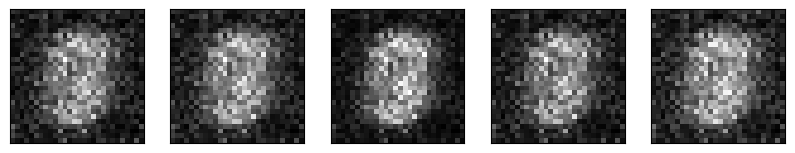

ÉPOCA 003 finalizada: custo discriminador 1.065848 - custo gerador 3.483985      


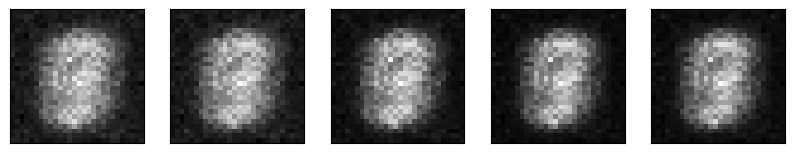

ÉPOCA 004 finalizada: custo discriminador 1.119266 - custo gerador 1.977997      


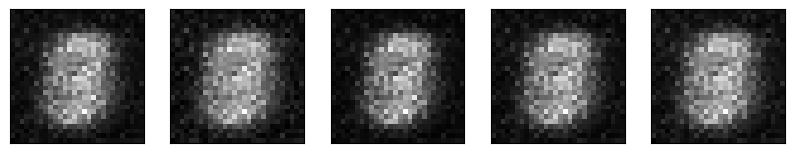

ÉPOCA 005 finalizada: custo discriminador 1.165546 - custo gerador 1.688936      


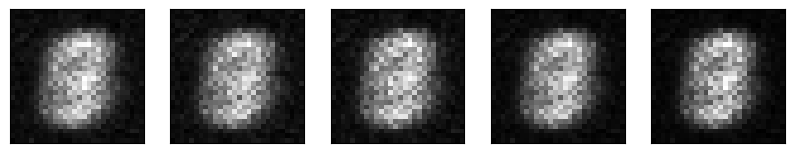

ÉPOCA 006 finalizada: custo discriminador 1.140561 - custo gerador 1.542966      


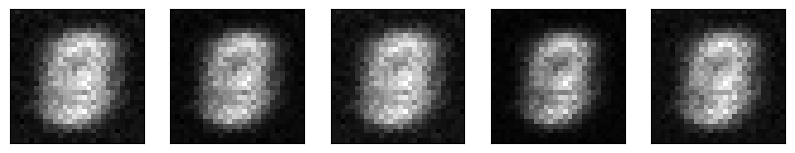

ÉPOCA 007 finalizada: custo discriminador 0.979138 - custo gerador 2.177984      


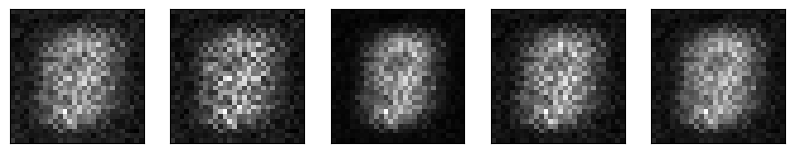

ÉPOCA 008 finalizada: custo discriminador 0.895892 - custo gerador 2.503292      


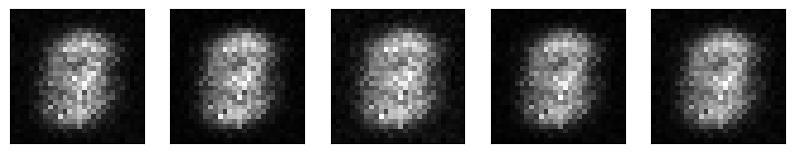

ÉPOCA 009 finalizada: custo discriminador 0.899258 - custo gerador 2.240555      


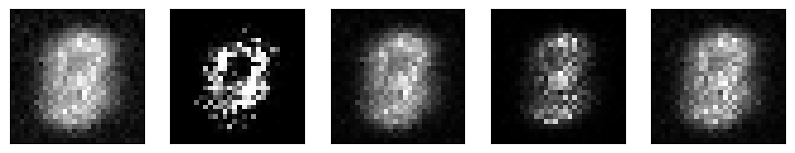

ÉPOCA 010 finalizada: custo discriminador 1.007994 - custo gerador 1.925048      


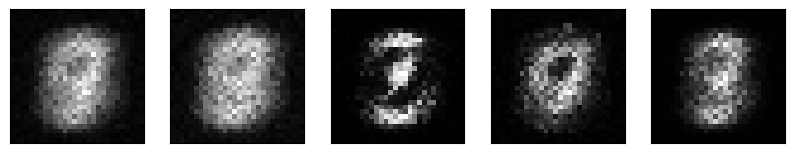

ÉPOCA 011 finalizada: custo discriminador 0.894999 - custo gerador 2.235562      


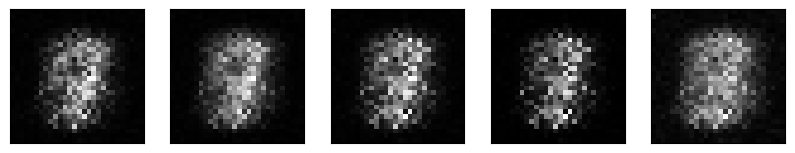

ÉPOCA 012 finalizada: custo discriminador 0.878403 - custo gerador 2.129919      


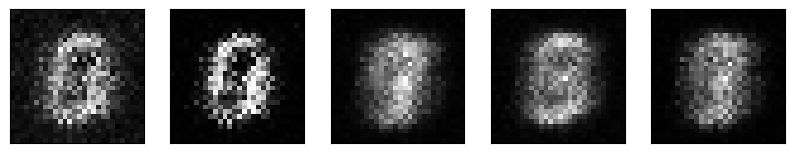

ÉPOCA 013 finalizada: custo discriminador 0.886153 - custo gerador 2.343593      


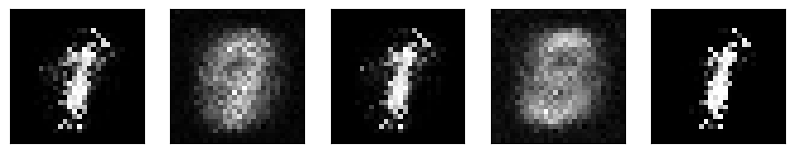

ÉPOCA 014 finalizada: custo discriminador 0.936284 - custo gerador 2.138889      


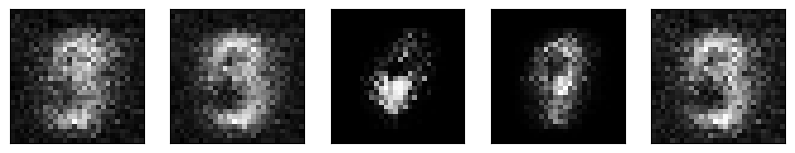

ÉPOCA 015 finalizada: custo discriminador 0.990805 - custo gerador 2.073840      


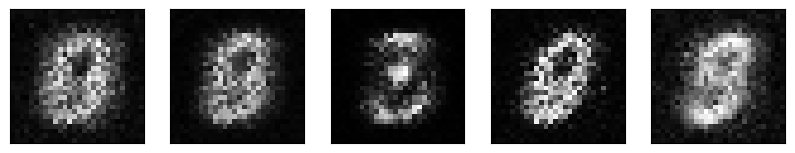

ÉPOCA 016 finalizada: custo discriminador 1.024818 - custo gerador 1.757501      


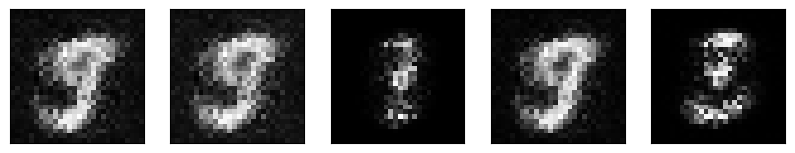

ÉPOCA 017 finalizada: custo discriminador 0.907940 - custo gerador 2.200379      


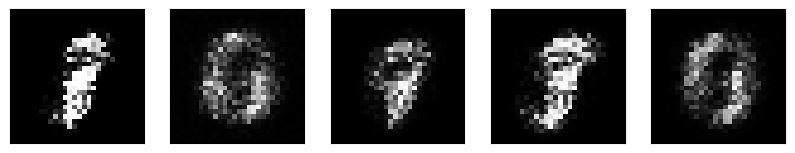

ÉPOCA 018 finalizada: custo discriminador 0.976940 - custo gerador 2.102614      


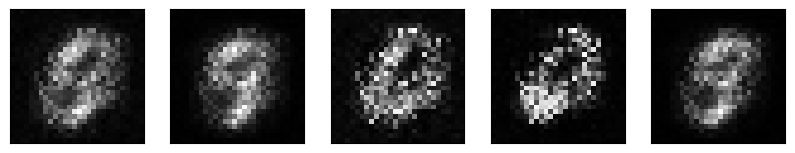

ÉPOCA 019 finalizada: custo discriminador 1.067498 - custo gerador 1.870154      


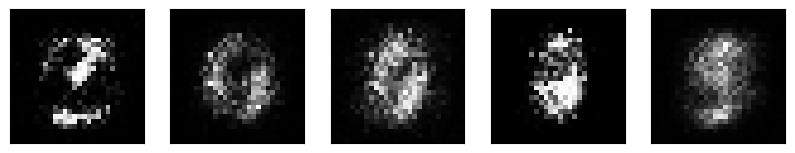

ÉPOCA 020 finalizada: custo discriminador 1.090082 - custo gerador 1.713697      


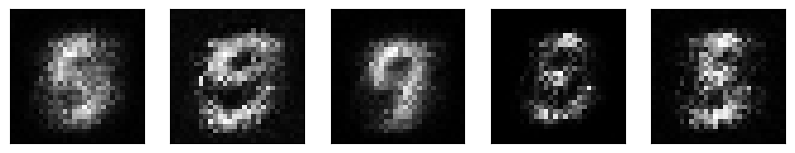

ÉPOCA 021 finalizada: custo discriminador 1.105240 - custo gerador 1.823663      


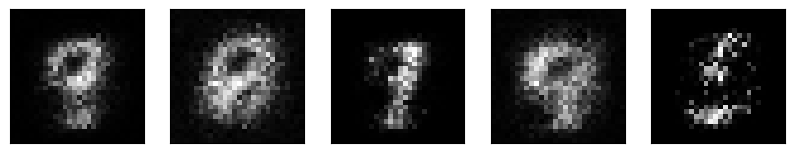

ÉPOCA 022 finalizada: custo discriminador 1.091859 - custo gerador 1.679160      


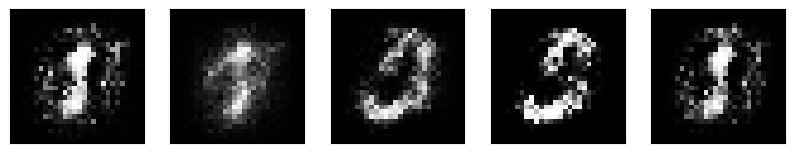

ÉPOCA 023 finalizada: custo discriminador 1.090506 - custo gerador 1.630931      


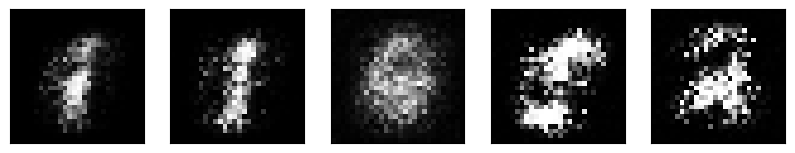

ÉPOCA 024 finalizada: custo discriminador 1.091846 - custo gerador 1.685860      


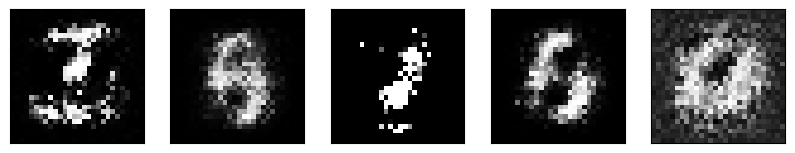

ÉPOCA 025 finalizada: custo discriminador 1.150993 - custo gerador 1.553427      


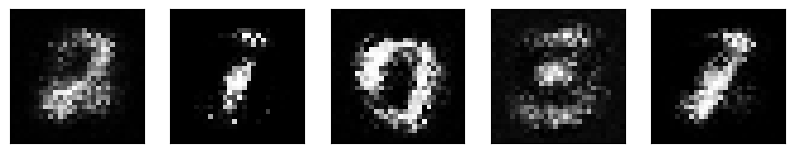

ÉPOCA 026 finalizada: custo discriminador 1.164478 - custo gerador 1.423108      


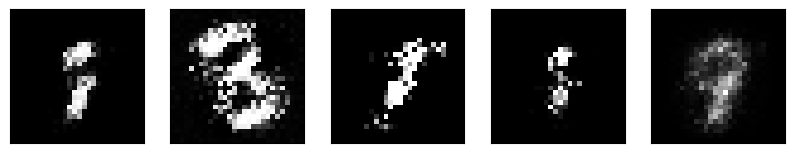

ÉPOCA 027 finalizada: custo discriminador 1.126129 - custo gerador 1.536063      


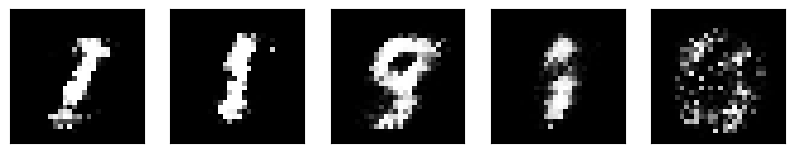

ÉPOCA 028 finalizada: custo discriminador 1.110319 - custo gerador 1.580134      


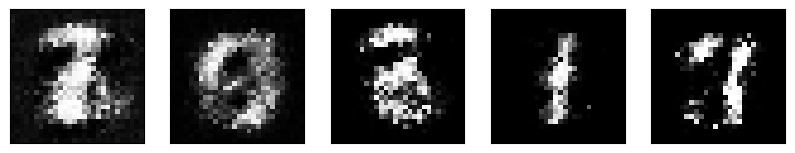

ÉPOCA 029 finalizada: custo discriminador 1.146988 - custo gerador 1.482934      


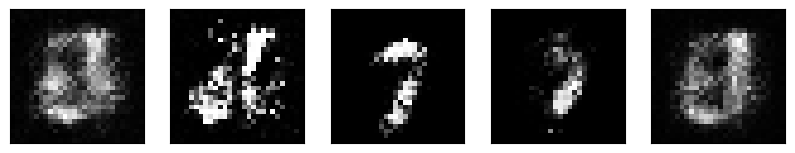

ÉPOCA 030 finalizada: custo discriminador 1.135887 - custo gerador 1.485029      


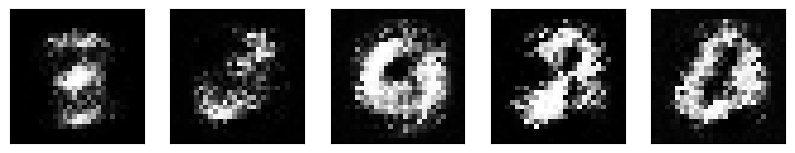

ÉPOCA 031 finalizada: custo discriminador 1.162267 - custo gerador 1.392582      


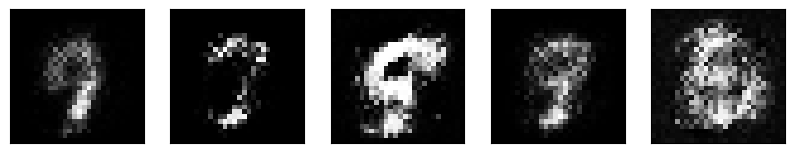

ÉPOCA 032 finalizada: custo discriminador 1.166554 - custo gerador 1.412658      


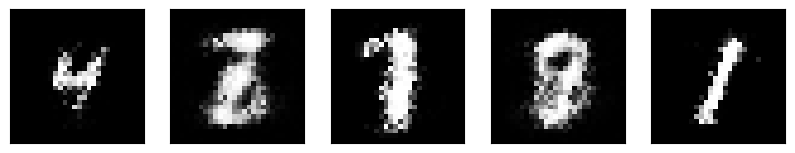

ÉPOCA 033 finalizada: custo discriminador 1.173860 - custo gerador 1.340640      


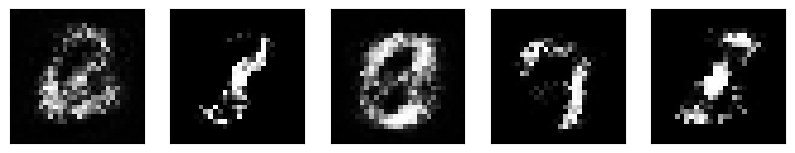

ÉPOCA 034 finalizada: custo discriminador 1.166340 - custo gerador 1.388101      


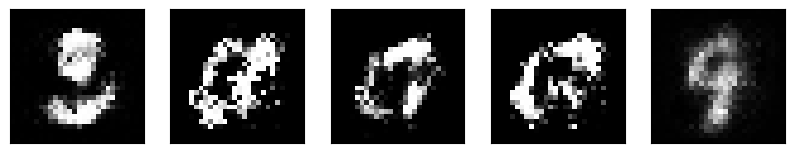

ÉPOCA 035 finalizada: custo discriminador 1.190998 - custo gerador 1.313633      


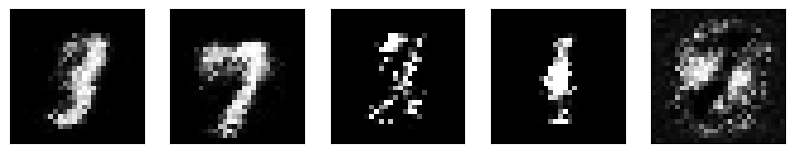

ÉPOCA 036 finalizada: custo discriminador 1.179376 - custo gerador 1.371060      


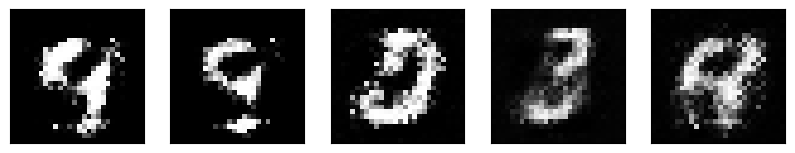

ÉPOCA 037 finalizada: custo discriminador 1.190073 - custo gerador 1.358625      


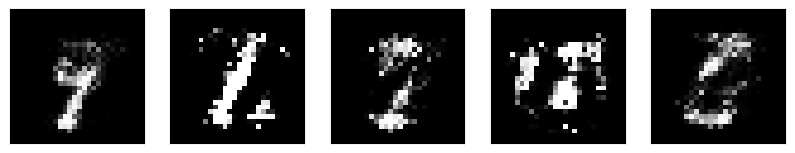

ÉPOCA 038 finalizada: custo discriminador 1.193613 - custo gerador 1.334952      


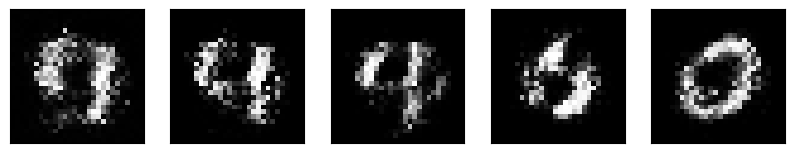

ÉPOCA 039 finalizada: custo discriminador 1.196659 - custo gerador 1.334473      


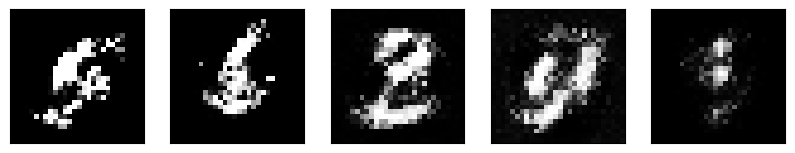

ÉPOCA 040 finalizada: custo discriminador 1.197212 - custo gerador 1.375215      


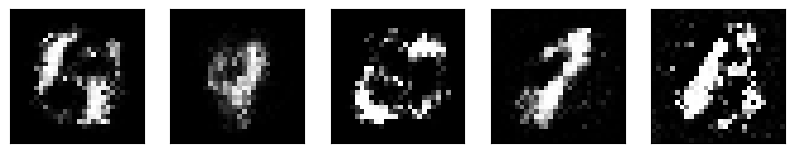

ÉPOCA 041 finalizada: custo discriminador 1.205615 - custo gerador 1.371075      


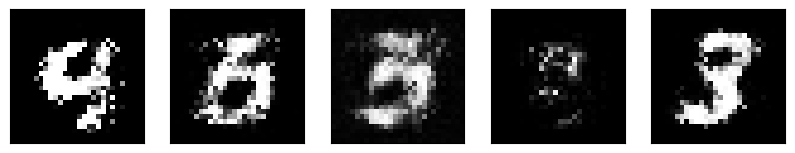

ÉPOCA 042 finalizada: custo discriminador 1.205975 - custo gerador 1.295911      


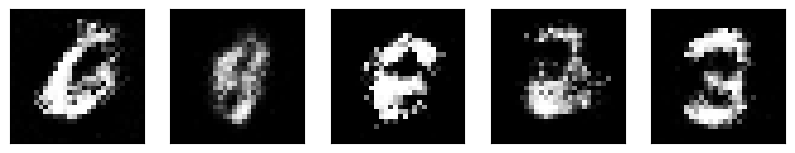

ÉPOCA 043 finalizada: custo discriminador 1.209338 - custo gerador 1.341978      


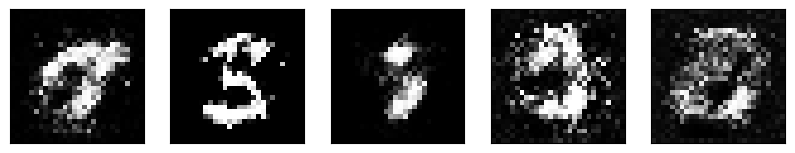

ÉPOCA 044 finalizada: custo discriminador 1.211666 - custo gerador 1.306065      


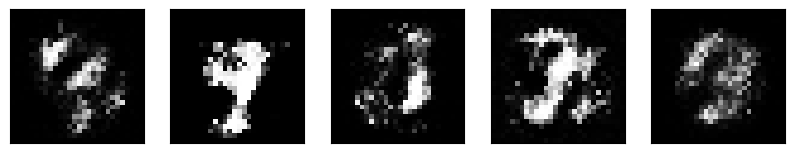

ÉPOCA 045 finalizada: custo discriminador 1.207787 - custo gerador 1.313575      


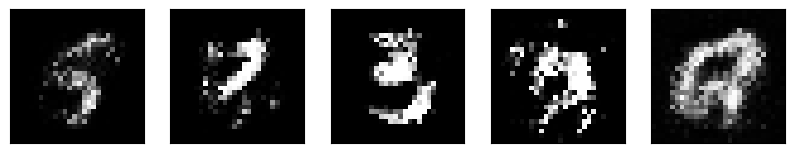

ÉPOCA 046 finalizada: custo discriminador 1.225734 - custo gerador 1.199520      


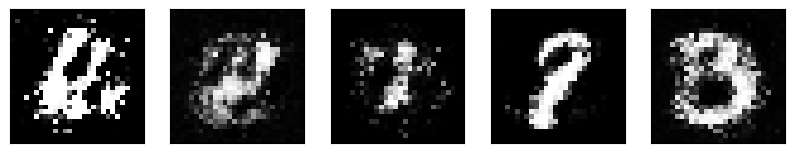

ÉPOCA 047 finalizada: custo discriminador 1.224441 - custo gerador 1.260654      


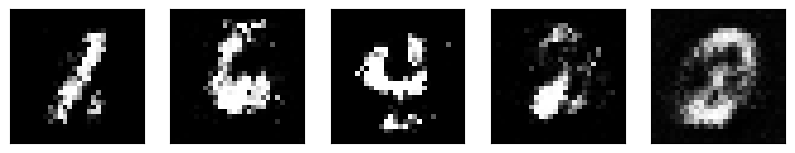

ÉPOCA 048 finalizada: custo discriminador 1.217208 - custo gerador 1.246920      


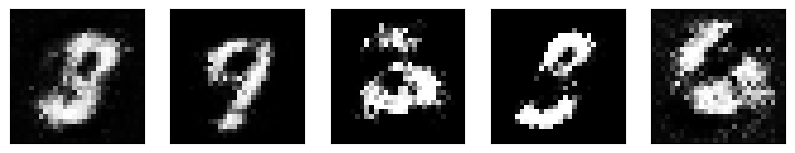

ÉPOCA 049 finalizada: custo discriminador 1.227910 - custo gerador 1.192687      


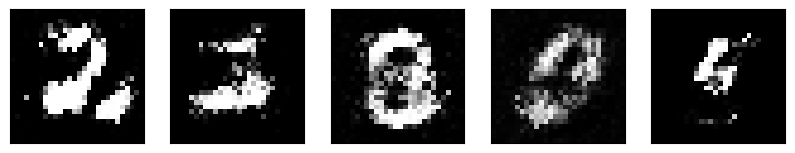

ÉPOCA 050 finalizada: custo discriminador 1.248978 - custo gerador 1.123363      


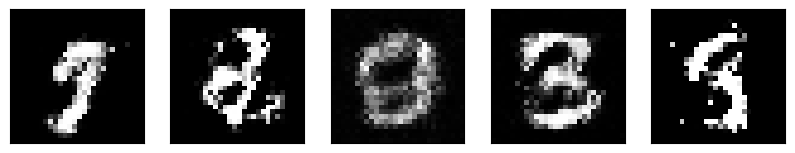

ÉPOCA 051 finalizada: custo discriminador 1.244253 - custo gerador 1.126519      


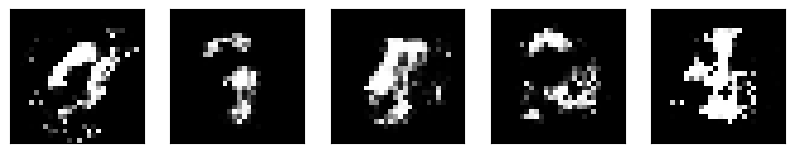

ÉPOCA 052 finalizada: custo discriminador 1.257694 - custo gerador 1.077869      


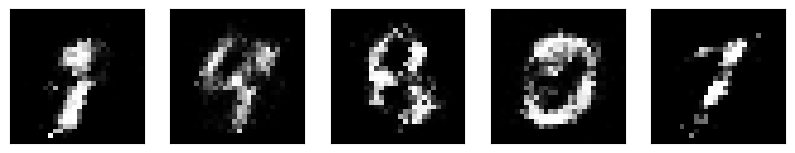

ÉPOCA 053 finalizada: custo discriminador 1.259686 - custo gerador 1.079097      


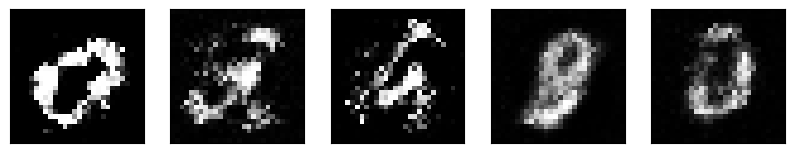

ÉPOCA 054 finalizada: custo discriminador 1.279060 - custo gerador 1.065602      


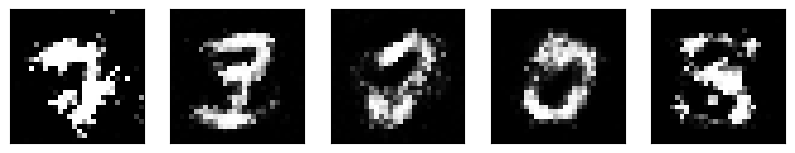

ÉPOCA 055 finalizada: custo discriminador 1.264653 - custo gerador 1.118498      


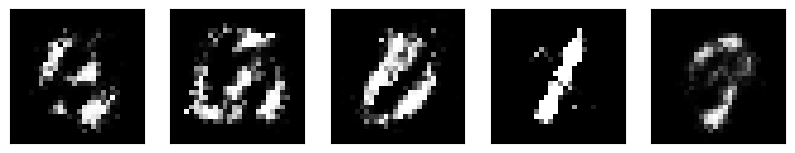

ÉPOCA 056 finalizada: custo discriminador 1.280011 - custo gerador 1.085298      


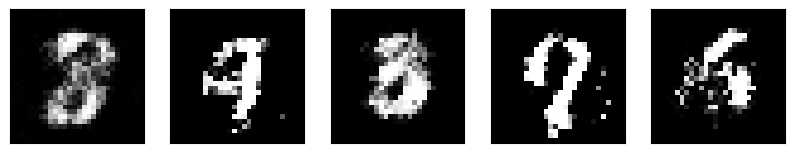

ÉPOCA 057 finalizada: custo discriminador 1.266518 - custo gerador 1.102821      


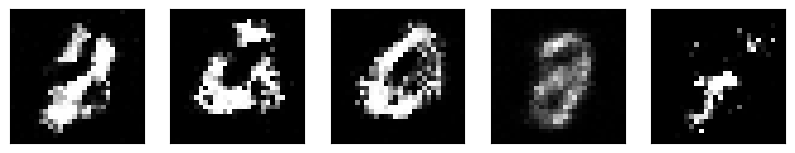

ÉPOCA 058 finalizada: custo discriminador 1.257198 - custo gerador 1.128635      


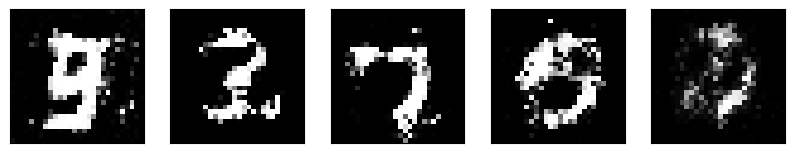

ÉPOCA 059 finalizada: custo discriminador 1.248221 - custo gerador 1.191299      


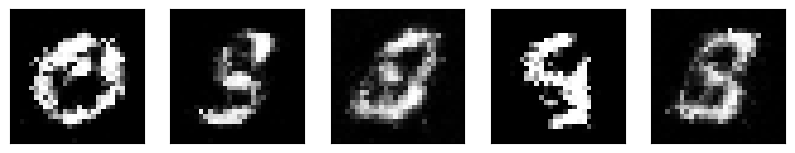

ÉPOCA 060 finalizada: custo discriminador 1.246352 - custo gerador 1.199074      


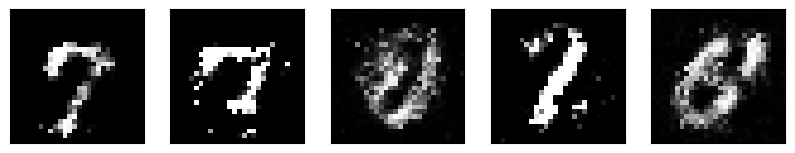

ÉPOCA 061 finalizada: custo discriminador 1.221704 - custo gerador 1.286776      


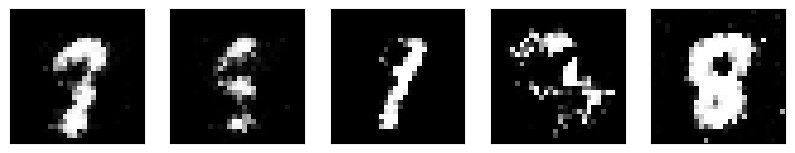

ÉPOCA 062 finalizada: custo discriminador 1.222591 - custo gerador 1.239072      


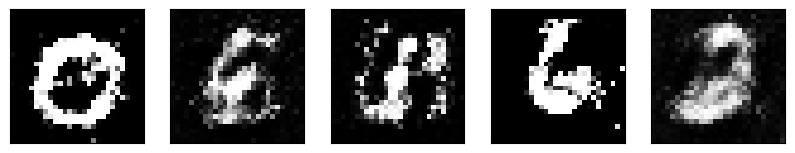

ÉPOCA 063 finalizada: custo discriminador 1.210224 - custo gerador 1.254646      


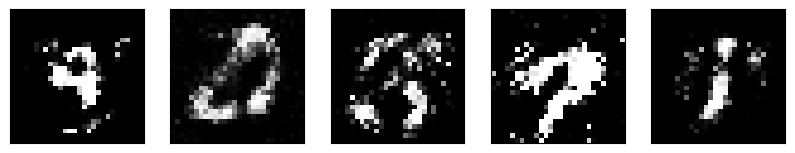

ÉPOCA 064 finalizada: custo discriminador 1.229814 - custo gerador 1.220092      


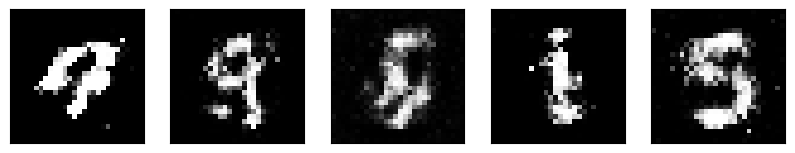

ÉPOCA 065 finalizada: custo discriminador 1.234845 - custo gerador 1.219904      


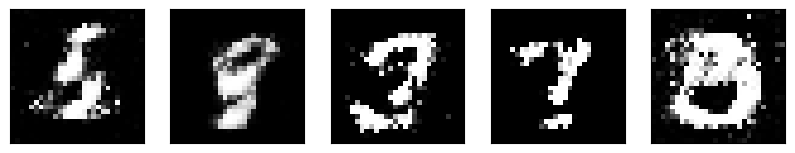

ÉPOCA 066 finalizada: custo discriminador 1.250741 - custo gerador 1.251486      


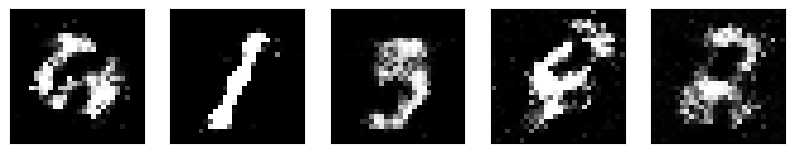

ÉPOCA 067 finalizada: custo discriminador 1.231396 - custo gerador 1.190047      


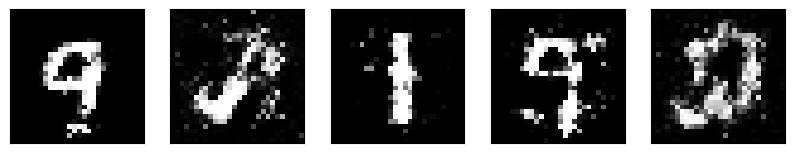

ÉPOCA 068 finalizada: custo discriminador 1.239906 - custo gerador 1.182757      


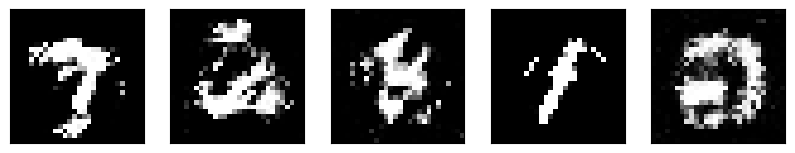

ÉPOCA 069 finalizada: custo discriminador 1.245088 - custo gerador 1.181428      


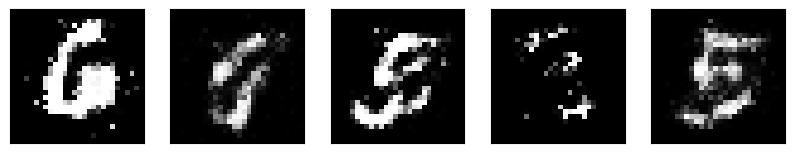

ÉPOCA 070 finalizada: custo discriminador 1.251767 - custo gerador 1.129975      


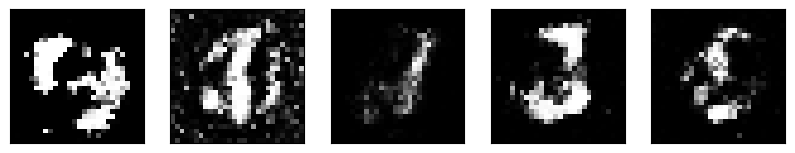

ÉPOCA 071 finalizada: custo discriminador 1.273264 - custo gerador 1.087566      


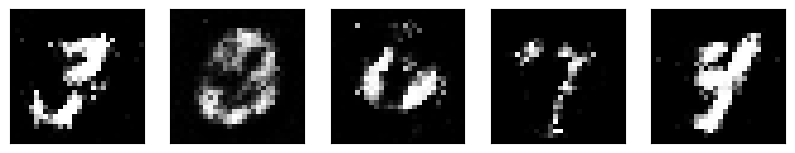

ÉPOCA 072 finalizada: custo discriminador 1.269841 - custo gerador 1.131567      


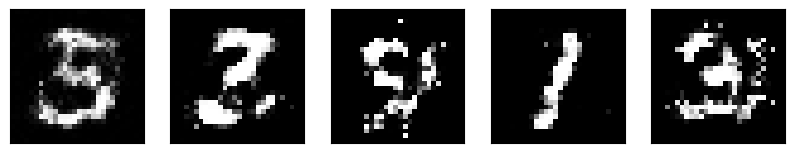

ÉPOCA 073 finalizada: custo discriminador 1.255472 - custo gerador 1.122367      


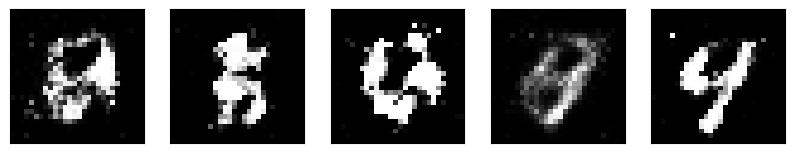

ÉPOCA 074 finalizada: custo discriminador 1.253384 - custo gerador 1.152517      


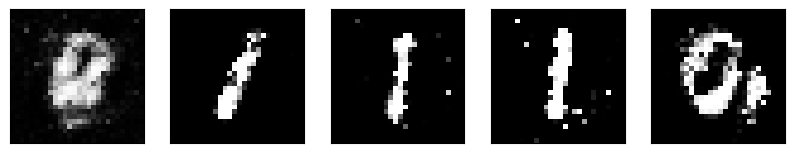

ÉPOCA 075 finalizada: custo discriminador 1.272687 - custo gerador 1.086109      


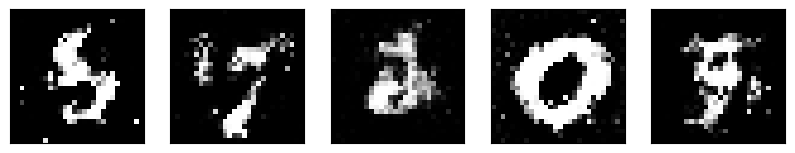

ÉPOCA 076 finalizada: custo discriminador 1.282313 - custo gerador 1.063853      


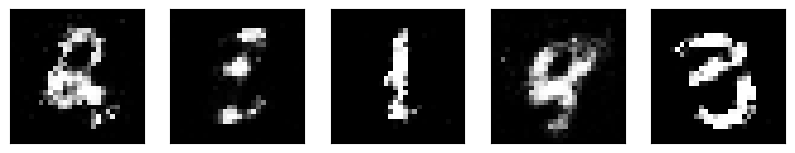

ÉPOCA 077 finalizada: custo discriminador 1.278453 - custo gerador 1.065757      


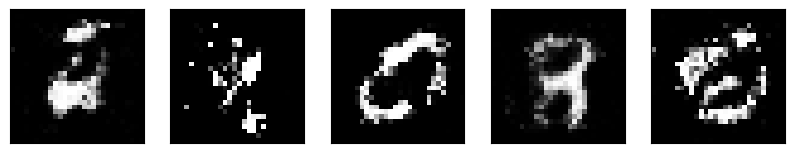

ÉPOCA 078 finalizada: custo discriminador 1.271467 - custo gerador 1.108559      


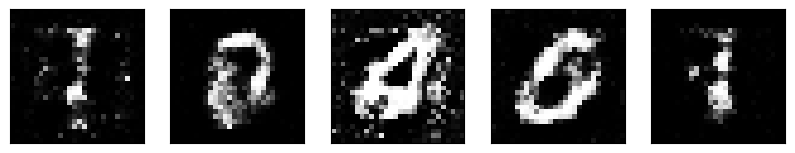

ÉPOCA 079 finalizada: custo discriminador 1.276523 - custo gerador 1.109284      


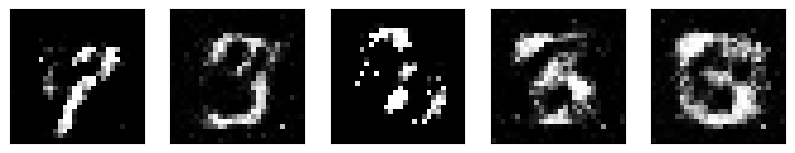

ÉPOCA 080 finalizada: custo discriminador 1.268702 - custo gerador 1.121713      


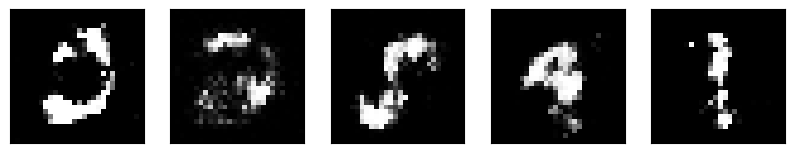

ÉPOCA 081 finalizada: custo discriminador 1.264595 - custo gerador 1.126977      


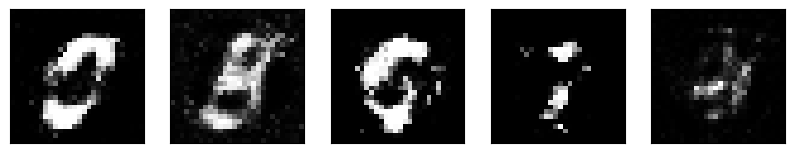

ÉPOCA 082 finalizada: custo discriminador 1.262037 - custo gerador 1.175830      


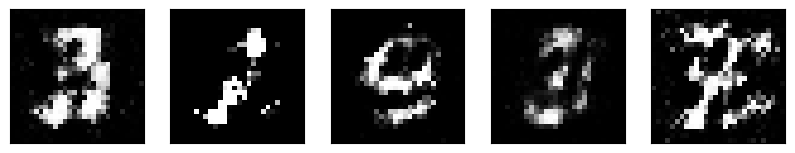

ÉPOCA 083 finalizada: custo discriminador 1.261766 - custo gerador 1.169767      


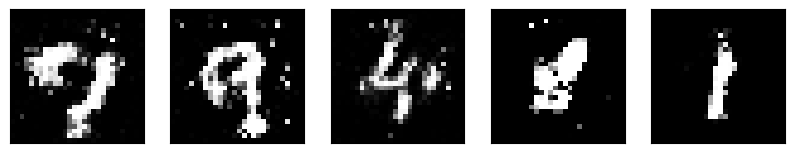

ÉPOCA 084 finalizada: custo discriminador 1.257614 - custo gerador 1.150929      


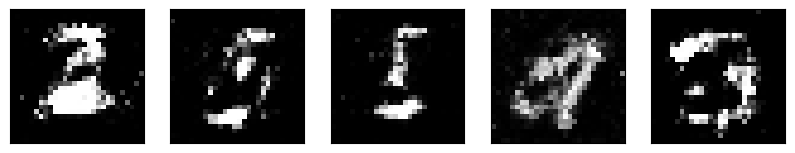

ÉPOCA 085 finalizada: custo discriminador 1.252279 - custo gerador 1.180623      


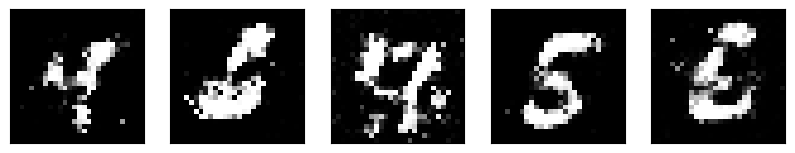

ÉPOCA 086 finalizada: custo discriminador 1.263940 - custo gerador 1.128927      


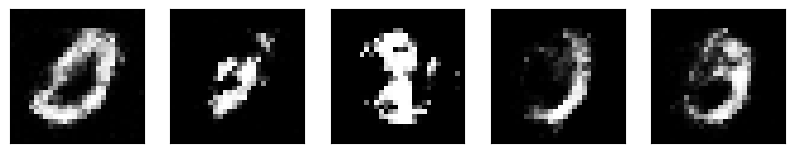

ÉPOCA 087 finalizada: custo discriminador 1.265838 - custo gerador 1.088150      


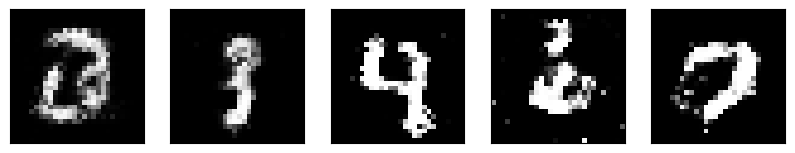

ÉPOCA 088 finalizada: custo discriminador 1.267378 - custo gerador 1.144253      


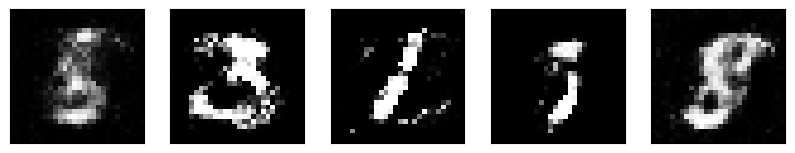

ÉPOCA 089 finalizada: custo discriminador 1.262686 - custo gerador 1.132530      


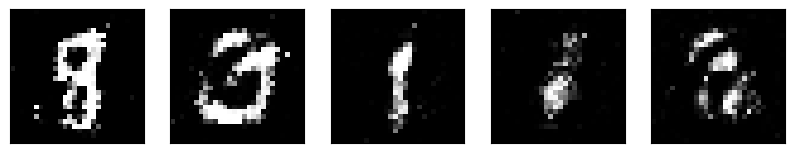

ÉPOCA 090 finalizada: custo discriminador 1.259614 - custo gerador 1.136523      


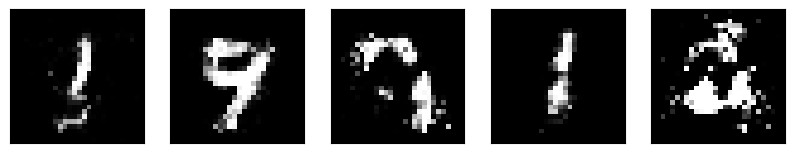

ÉPOCA 091 finalizada: custo discriminador 1.270606 - custo gerador 1.138844      


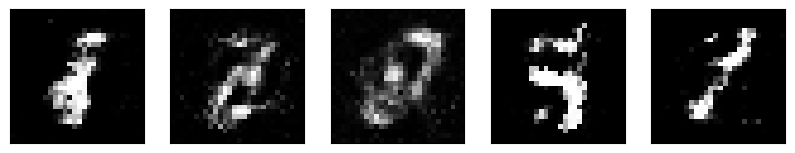

ÉPOCA 092 finalizada: custo discriminador 1.267616 - custo gerador 1.069510      


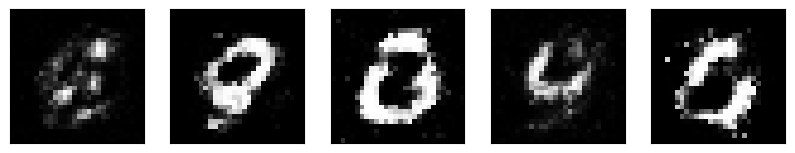

ÉPOCA 093 finalizada: custo discriminador 1.283094 - custo gerador 1.061945      


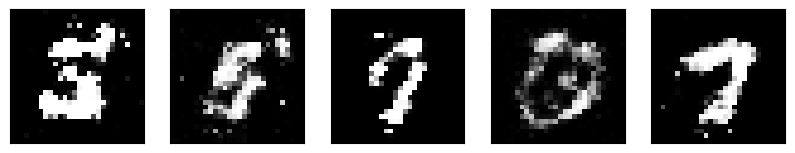

ÉPOCA 094 finalizada: custo discriminador 1.283519 - custo gerador 1.072641      


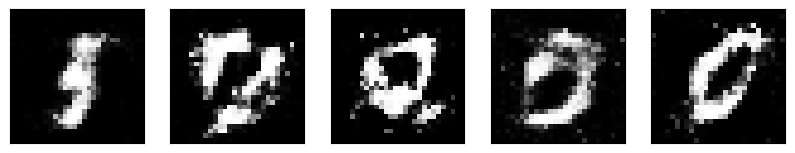

ÉPOCA 095 finalizada: custo discriminador 1.270813 - custo gerador 1.114939      


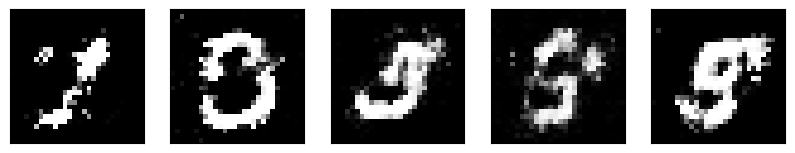

ÉPOCA 096 finalizada: custo discriminador 1.266111 - custo gerador 1.108219      


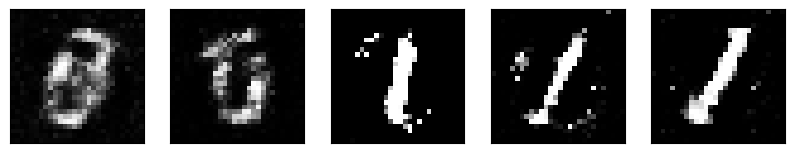

ÉPOCA 097 finalizada: custo discriminador 1.270608 - custo gerador 1.089097      


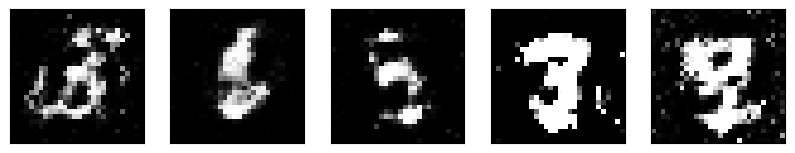

ÉPOCA 098 finalizada: custo discriminador 1.270614 - custo gerador 1.110866      


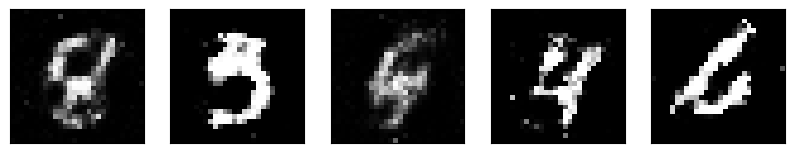

ÉPOCA 099 finalizada: custo discriminador 1.268702 - custo gerador 1.138642      


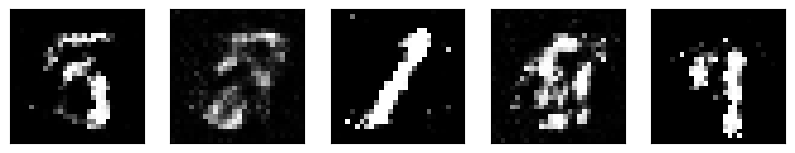

ÉPOCA 100 finalizada: custo discriminador 1.275594 - custo gerador 1.087303      


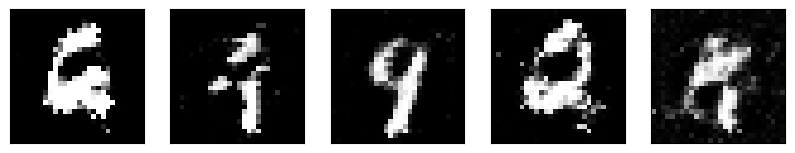

In [16]:
historico_D = []
historico_G = []
# Inicia o loop de treinamento por 100 épocas (iterações completas sobre o dataset)
# exemplo 50 epoch
for epoch in range(100):
    # Inicializa acumuladores para calcular a média do erro (loss) ao final da época
    D_running_loss = 0
    G_running_loss = 0
    
    # Percorre o DataLoader carregando lotes (batches) de imagens reais
    # train_loader=> retorna o pixels e as classes (sem retornar a classe agora, só o pixel)
    # 256 pixesl o processo será gerador (imagens_reais), criando 256 imagens reais e falsas
    for i, (imagens_reais, _) in enumerate(train_loader): 
        batch_size = imagens_reais.size(0)
        
        # Normaliza as imagens de [0, 1] para [-1, 1] para combinar com a ativação Tanh do Gerador
        imagens_reais = imagens_reais * 2 - 1  # para ficar na mesma escala
        imagens_reais = imagens_reais.to(device)

        
        # --- TREINAMENTO DO GERADOR (G) ---
        # Treinamento do gerador
        
        G_optimizer.zero_grad() # Limpa gradientes anteriores
        # Cria ruído aleatório como entrada para o Gerador, valores como float
        # ruido de -1. a 1. Primeira etapa do gerador, entrada de valores aleatórios.
        # camada de entrada com 100 neurônios
        ruido = np.random.uniform(low=-1., high=1., size=(batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device) # transformar em float do pytorch
        # ruído para a rede neural, no começo só ruído.
        # * O Gerador tenta criar imagens a partir do ruído
        # passar  o ruído para a estrutura da rede neural forward
        imagens_falsas = G.forward(ruido)
        # * O Gerador passa as imagens falsas para o Discriminador (D)
        # passando a imagem para o discriminador
        # * Lembrando que a função do discriminador indica o quão longe o gerador está de gerar imagens reais. 
        # passando para o discriminador, no final do neurônio da saída, é apenas , se é ou não de um aninal ou não. 
        # se 1 próximo de ser um cachorro, por exemplo
        outputs_falsas = D.forward(imagens_falsas)

        # O objetivo do Gerador é que o D ache que elas são REAIS (label 1)
        # labels com um valor 1, vetor com 256 posições (batch sizes), e com todas as posições temos o valor 1.
        labels_falsas = torch.ones(batch_size).to(device)

        # Calcula o erro baseado no quão longe o D está de ser enganado
        # criterion, função do erro. E o view é para deixar tudo na mesma dimensionalidade
        # previsão da rede neural com o labels falsas com o valor 1.
        # sempre comparar com o valor 1, para ver se enganha ou não;. Indo para o gerador, para criar novas imagens e aprender.
        G_loss = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)
        
        G_loss.backward()  # Backpropagation para o Gerador
        G_optimizer.step() # Atualiza os pesos do Gerador. Iteração como mostra na figura acima 2.
        
        
        # --- TREINAMENTO DO DISCRIMINADOR (D) ---
        # Treinamento do discriminador
        D_optimizer.zero_grad() # Limpa gradientes do Discriminador
        # Parte 1: Treina com imagens REAIS * do trainer loader 60mil imagens da base de dados
        outputs_reais = D.forward(imagens_reais)
       # Usa 0.9 (Label Smoothing) em vez de 1.0 para ajudar na estabilidade do treino    
        # 0.9 suavizar as imagens, score de 90% de chance para classificar uma imagem real. 
        labels_reais = (torch.ones(batch_size) * 0.9).to(device) # batch size quantidade de imagens e mandar para a cpu
        # criterion, valor do erro, com conversão view. 
        D_loss_reais = criterion(outputs_reais.view(*labels_reais.shape), labels_reais)
        
        # Parte 2: Treina com imagens FALSAS (geradas novamente para atualizar o gradiente)
        # para gerar no discriminador o valor esperado 0, falso, criando valor aleatório de -1 a 1
        # criando 256 imagens ou ruídos, cada um com 100 posições
        ruido = np.random.uniform(-1., 1., (batch_size, 100))
        # ruídos gerados
        ruido = torch.from_numpy(ruido).float().to(device)
        # imagem falsa gerador foward
        imagens_falsas = G.forward(ruido)
        
        # calcular as imagens falsas e exportar para mostrar
        outputs_falsas = D.forward(imagens_falsas)
        # Aqui o Discriminador deve identificar que são FALSAS (label 0)
        labels_falsas = torch.zeros(batch_size).to(device) # valor zero, pois esperamos o valor falso = 0 na saída
        # d loss erro, criterion
        D_loss_falsas = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)
        # custo associado as imagens reais e os falsos. 
        # Erro total do D é a soma do erro das reais + erro das falsas
        D_loss = D_loss_reais + D_loss_falsas
        # processo de atualização
        D_loss.backward() # Backpropagation para o Discriminador
        D_optimizer.step() # Atualiza os pesos do Discriminador, de fato atualizar.
        
        # Acumula os custos para o relatório da época
        # atualização dos dados 
        D_running_loss += D_loss.item()
        G_running_loss += G_loss.item()
        
        # Mostra o progresso em tempo real dentro do loop de batches
        # Imprimindo os dados referentes a esse batch
        print('\rÉpoca {:03d} - Loop {:3d} de {:3d}: custo discriminador {:03.5f} - custo gerador {:03.5f}'.format(
            epoch + 1, 
            i + 1, len(train_loader), 
            D_loss.item(), 
            G_loss.item()), end = '\r'
             )
        
    # Ao final de cada época, calcula a média do custo e imprime
    # Imprimindo os dados referentes a essa época
    D_running_loss /= len(train_loader)
    G_running_loss /= len(train_loader)
    print('ÉPOCA {:03d} finalizada: custo discriminador {:03.6f} - custo gerador {:03.6f}      '.format(epoch + 1,
                                                                                                        D_running_loss,
                                                                                                        G_running_loss))
    
    # Guardando as médias para o gráfico
    historico_D.append(D_running_loss)
    historico_G.append(G_running_loss)
    
    # Visualização: Plota 5 imagens geradas para acompanhar a evolução visual da IA
    fig, ax = plt.subplots(1, 5, figsize=(10,5))
    for i in range(5):
      # Converte de volta para CPU, desvincula do grafo e redimensiona para 28x28 (formato MNIST)      
      ax[i].imshow(imagens_falsas.cpu().detach().numpy()[i].reshape(28, 28), cmap='gray')
      ax[i].xaxis.set_visible(False)
      ax[i].yaxis.set_visible(False)
    plt.show()


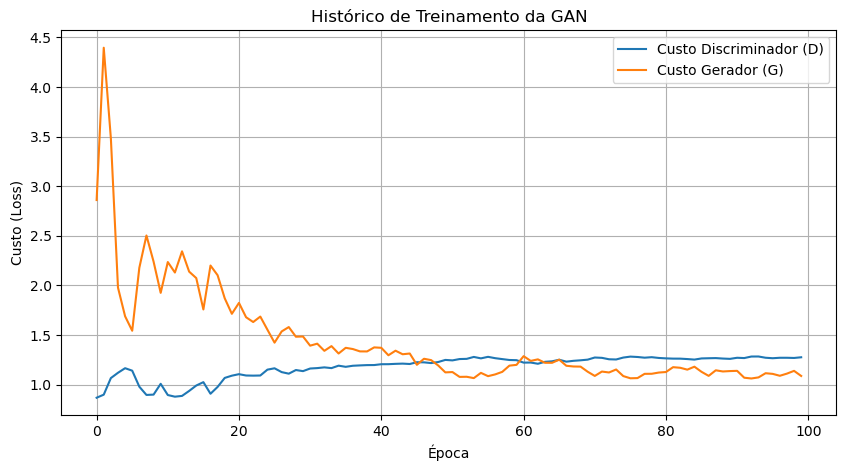

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(historico_D, label='Custo Discriminador (D)')
plt.plot(historico_G, label='Custo Gerador (G)')
plt.title('Histórico de Treinamento da GAN')
plt.xlabel('Época')
plt.ylabel('Custo (Loss)')
plt.legend()
plt.grid(True)
plt.show()

🔍 O que observar no gráfico real:

Equilíbrio: Diferente de uma rede neural comum onde o erro deve chegar próximo de zero, em uma GAN o ideal é que os dois custos fiquem oscilando. Se o D_loss cair para zero, o Discriminador ficou perfeito demais e o Gerador não consegue mais aprender (o gradiente desaparece).

Overfitting do Discriminador: Se a linha do Discriminador cair muito e a do Gerador subir sem parar, o Discriminador "decorou" as imagens reais. O Label Smoothing (0.9) que usamos
serve justamente para evitar que isso aconteça rápido demais!

Mode Collapse: Se o erro do Gerador ficar muito baixo mas as imagens geradas forem todas iguais, ele encontrou um "atalho" e parou de diversificar.

In [18]:
# imagens aleatórios passam as épocas as imagens dos números melhoram mais a visualização. 
# imagens não existem, foram criadas pela rede neural.

## Etapa 7: Criação de novas imagens

## Geração das novas imagens com as GANs, passando o ruído

# gerar valores entre -1 e 1, aplicação da tangente hiperbólica, gerando 20 imagens, 100 números aleatórios serão passados

com 20 linhas e 100 colunas, 

Ruídos números aleatórios. 


# ruídos aleatórios, gerando imagens, de 0 a 9.
# ruído mudado para o formato pytoch. 

In [19]:
ruido = np.random.uniform(-1., 1., (20, 100))

In [20]:
ruido[1]

array([-0.99889273, -0.49183154,  0.45617193, -0.13728033,  0.73341631,
       -0.04725211, -0.88040993, -0.49324555, -0.98392214,  0.09498088,
        0.87950503,  0.03802694, -0.36476002, -0.34020735, -0.81417258,
       -0.65018284, -0.57579748,  0.45490763,  0.24632549, -0.37760562,
        0.78348598, -0.03291896,  0.28578059,  0.71787622, -0.66290061,
       -0.68341984, -0.46159564, -0.07297853,  0.50121932,  0.97833413,
       -0.37464211,  0.97003065, -0.07917201,  0.25044618,  0.1854055 ,
        0.71147752, -0.3934216 ,  0.63979434,  0.83596579, -0.76958393,
        0.86850755, -0.68367807, -0.45198317, -0.93535158, -0.30128906,
        0.62036145,  0.50093087,  0.8974731 , -0.81100187, -0.44304397,
        0.19749747,  0.18755361, -0.47457493,  0.87986316, -0.19686783,
        0.09894475, -0.6475161 , -0.12667482,  0.2706818 , -0.59265594,
        0.16702727, -0.31414313,  0.24972814, -0.59867593,  0.19650207,
        0.59056277,  0.59200759,  0.26239877, -0.08285163,  0.86

In [21]:
# converter para pytorch
ruido = torch.from_numpy(ruido).float().to(device)

In [22]:
# formato tensor
type(ruido)


torch.Tensor

In [23]:
G.eval() # gerador em formato de avaliação
previsao = G.forward(ruido) # previsão pelo forward, valores 

In [24]:
previsao.shape[0]

20

In [25]:
previsao[0] # primeira imagem gerada

tensor([[-1.0000, -0.9999, -1.0000, -1.0000, -0.9999, -1.0000, -1.0000, -1.0000,
         -1.0000, -0.9999, -0.9998, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -0.9999,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -0.9998, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
         -1.0000, -1.0000, -1.0000, -1.0000, -1.0000

In [26]:
# tirar do formato tensor
previsao = previsao.cpu().detach().numpy()

In [27]:
previsao[0] # primeira imagem gerada, formato numpy array

array([[-0.9999943 , -0.99994344, -0.9999956 , -0.999996  , -0.99993527,
        -0.9999977 , -0.99997246, -0.99999905, -0.9999964 , -0.9999249 ,
        -0.99978155, -0.9999898 , -0.9999978 , -0.9999966 , -0.99999547,
        -0.99997157, -0.9999979 , -0.99999183, -0.9999963 , -0.9999875 ,
        -0.99999577, -0.9999953 , -0.99998426, -0.99999845, -0.999991  ,
        -0.99998695, -0.99999034, -0.99999636],
       [-0.9999858 , -0.9999958 , -0.9999974 , -0.9999916 , -0.99998116,
        -0.9999902 , -0.9999939 , -0.9999379 , -0.9999956 , -0.9999898 ,
        -0.9999862 , -0.99999666, -0.99999946, -0.9999999 , -0.99999803,
        -0.99999845, -0.99997836, -0.9999998 , -0.9999639 , -0.9999968 ,
        -0.9999994 , -0.9999988 , -0.99999076, -0.99997014, -0.9999677 ,
        -0.9999994 , -0.9999966 , -0.99999654],
       [-0.9999936 , -0.9999963 , -0.9999698 , -0.99999565, -0.99976903,
        -0.9999967 , -0.99999917, -0.9999848 , -0.9999946 , -0.9999991 ,
        -0.9999987 , -0.9999

In [28]:
# rodar 20 vezes
previsao.shape[0]

20

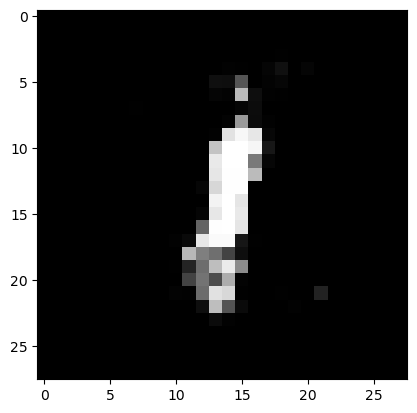

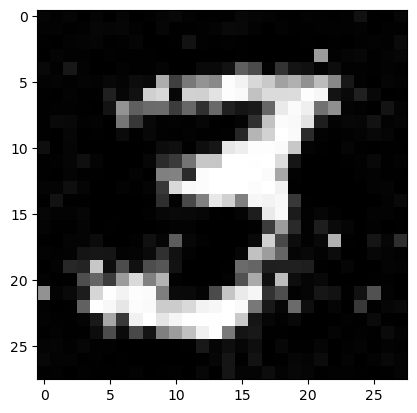

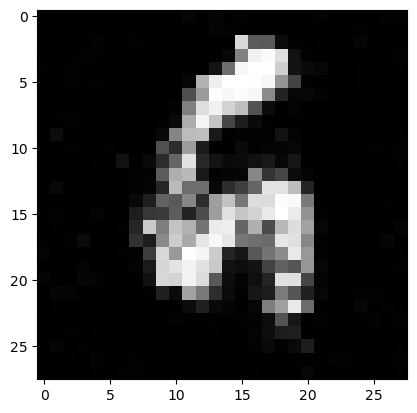

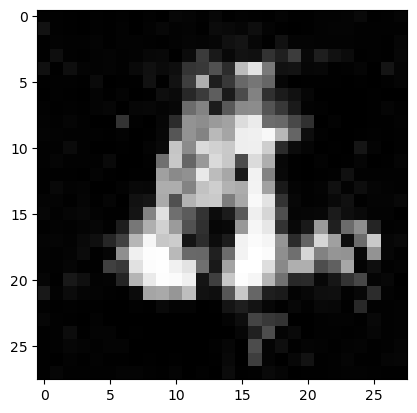

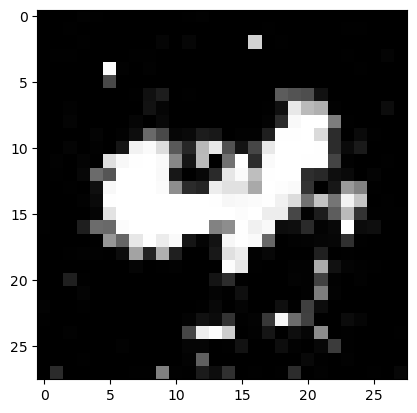

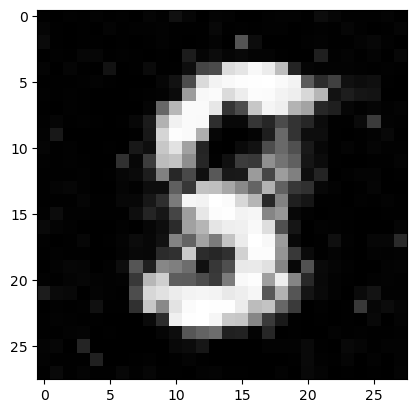

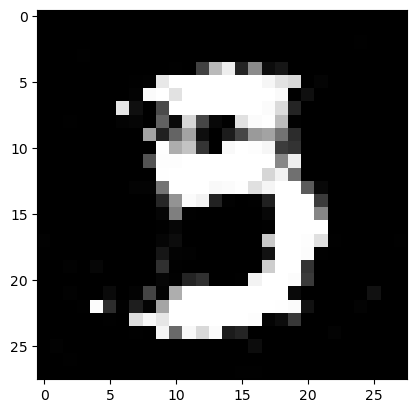

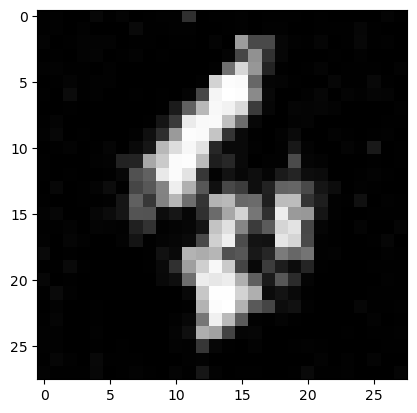

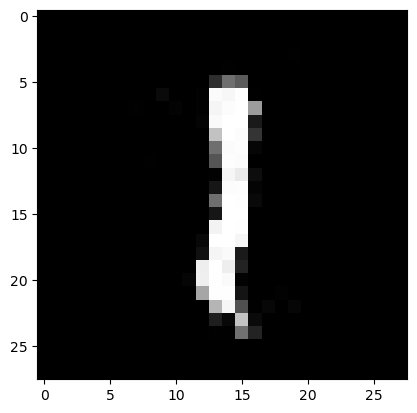

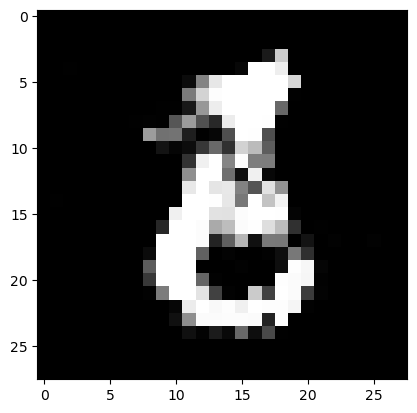

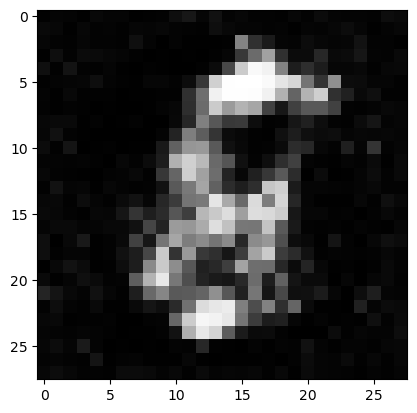

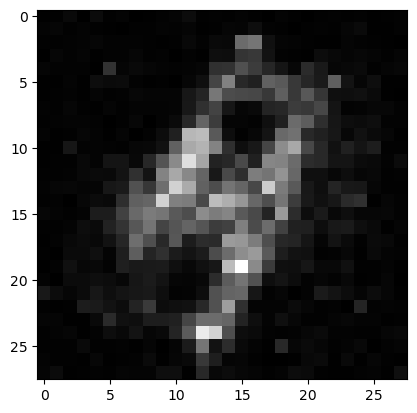

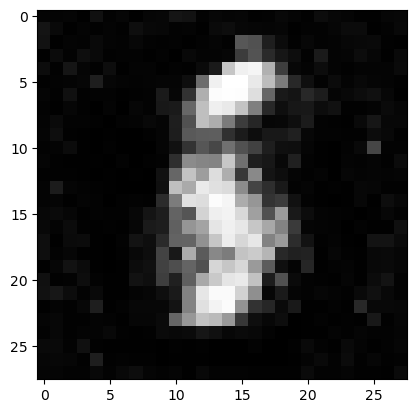

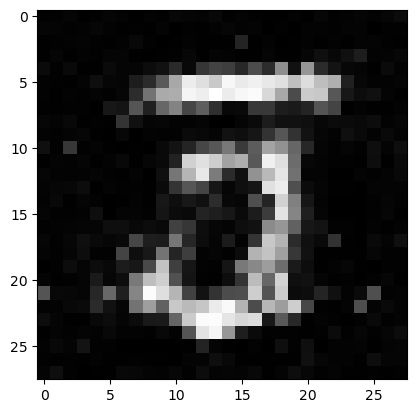

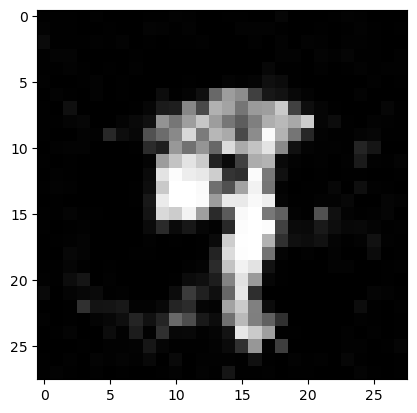

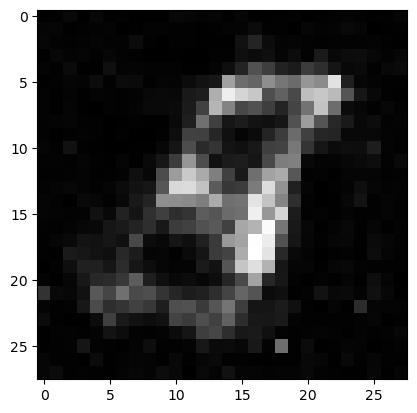

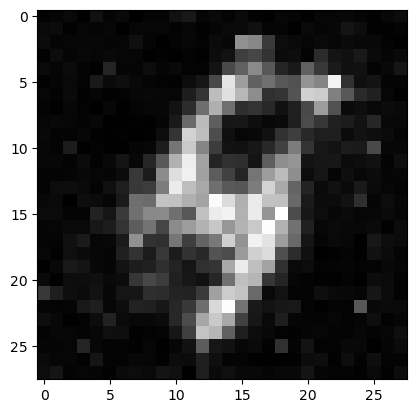

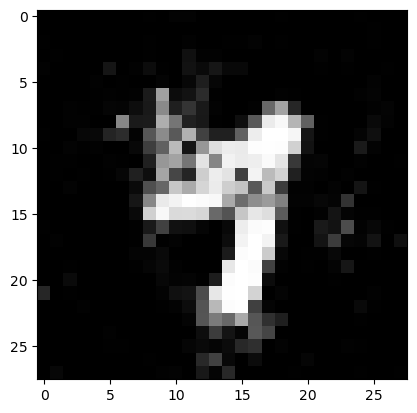

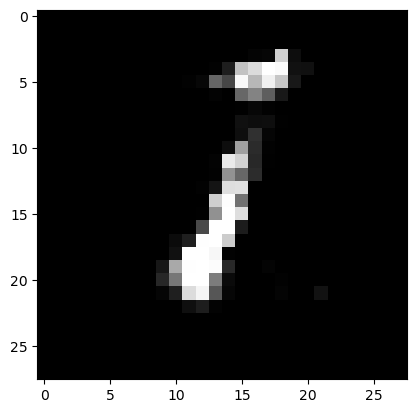

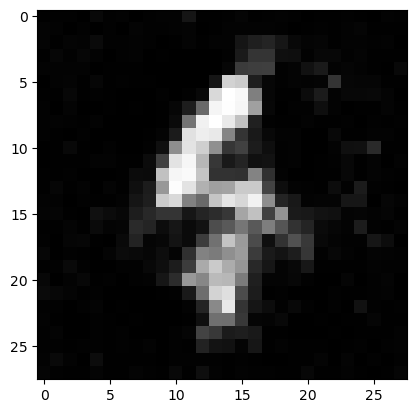

In [29]:
for i in range(previsao.shape[0]): # rodar 20 ruídos
  plt.imshow(previsao[i, :].squeeze(), cmap='gray')
  plt.show()

## exemplos

In [ ]:
# ao invés de rodar a rede neural densa, podemos rodar a rede neura convolucional. 
# na parte do discriminador. 
# ao inves do nn.linear, adicionar mais camadas. 

In [ ]:
# versões abaixo:

In [32]:
import torch.nn as nn

class Discriminador_versao2(nn.Module):
    def __init__(self):
        super(Discriminador, self).__init__()
        self.main = nn.Sequential(
            # Entrada: (1, 28, 28) - 1 canal de cor (cinza), 28x28 pixels
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Segunda camada: reduz ainda mais a imagem
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Achata (Flatten) para converter os mapas de feições em um único valor
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Como o MNIST no DataLoader vem (B, 1, 28, 28), não precisa de .view(-1, 784)!
        return self.main(x)

In [33]:
import torch.nn as nn

class Discriminador_versao2(nn.Module):
    def __init__(self):
        super(Discriminador, self).__init__()
        self.main = nn.Sequential(
            # Entrada: 784 pixels -> 128 neurônios
            nn.Linear(784, 128),
            nn.LeakyReLU(0.2), # Ativação padrão para GANs
            
            # 128 -> 64 neurônios
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            
            # 64 -> 32 neurônios
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            # 32 -> 1 (Veredito final: Real ou Falso)
            nn.Linear(32, 1),
            nn.Sigmoid() # Garante que a saída esteja entre 0 e 1
        )

    def forward(self, x):
        # Achata a imagem de (28, 28) para (784)
        x = x.view(-1, 784)
        return self.main(x)

In [34]:
import torch.nn as nn

class DiscriminadorCNN_versao2_final(nn.Module):
    def __init__(self):
        super(DiscriminadorCNN, self).__init__()
        # A entrada é (1 canal, 28x28 pixels)
        self.main = nn.Sequential(
            # Camada 1: 1 -> 32 filtros. Reduz de 28x28 para 14x14
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Camada 2: 32 -> 64 filtros. Reduz de 14x14 para 7x7
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), # Estabiliza o treino
            nn.LeakyReLU(0.2, inplace=True),

            # Camada 3: 64 -> 128 filtros. Reduz de 7x7 para 4x4
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Veredito Final: 
            # Achata o volume (128 * 4 * 4) para um vetor
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 1), # Ajuste de tamanho dependendo do padding/stride
            nn.Sigmoid()
        )

    def forward(self, x):
        # IMPORTANTE: Se o seu input for (Batch, 784), 
        # precisamos remodelar para (Batch, 1 canal, 28, 28)
        if x.dim() == 2:
            x = x.view(-1, 1, 28, 28)
        return self.main(x)

In [35]:
class Gerador_versa2(nn.Module):
    def __init__(self):
        super(Gerador, self).__init__()
        # Começamos com uma camada linear para preparar o ruído
        self.fc = nn.Linear(100, 128 * 7 * 7)
        
        self.main = nn.Sequential(
            # Recebe o ruído moldado em 128 canais de 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # Upsample para 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Upsample para 28x28
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh() # Saída entre -1 e 1 para combinar com a normalização
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7) # "Remodela" o vetor para o formato de imagem
        return self.main(x)